https://www.nature.com/articles/s41422-020-0374-x

In [1]:
# Always reload packages before executing user code
%load_ext autoreload
%autoreload 2

In [2]:
# Basic imports
import scanpy as sc

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# convert to anndata

In [ ]:
import pandas as pd

# Path to raw AnnData file (adjust as needed)
path = '/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/GSE150430_npc_scRNA_hg19_processed_data.txt'


df = pd.read_csv(path, sep='\t')

display(df.head())

In [ ]:
import numpy as np
import anndata as ad
from scipy import sparse

if "Cell_type" not in df.index:
    raise ValueError("Expected a row named 'Cell_type' in the first column (gene names).")

cell_type = df.loc["Cell_type"].astype(str)

# 3) Drop that row from expression matrix
expr = df.drop(index="Cell_type")

# (optional but recommended) ensure unique gene names
expr.index = expr.index.astype(str)
expr = expr[~expr.index.duplicated(keep="first")]

# 4) Build obs (cell metadata)
cell_ids = expr.columns.astype(str)
samples = pd.Index(cell_ids).str.split("_", n=1).str[0]   # sample = before first "_"

obs = pd.DataFrame(
    {
        "cell_id": cell_ids,
        "cell_type": cell_type.loc[cell_ids].values,  # align to columns
        "sample": samples,
    },
    index=cell_ids,
)

# 5) Build var (gene metadata)
var = pd.DataFrame(index=expr.index)
var.index.name = "gene"

# 6) Create AnnData (cells x genes)
X = expr.to_numpy(dtype=np.float32).T  # cells x genes

# optional: sparse (usually better for scRNA)
X = sparse.csr_matrix(X)

adata = ad.AnnData(X=X, obs=obs, var=var)



print(adata.n_obs, adata.n_vars)

In [ ]:
adata.layers['log1p'] = adata.X.copy()

In [ ]:
adata.obs["cell_type"].value_counts()

In [ ]:
import numpy as np

ct = adata.obs["cell_type"].astype(str)

def to_broad_celltype(x: str) -> str:
    x = x.strip()

    # CAF
    if x == "CAFs":
        return "CAFs"

    # Epithelial (incl malignant/non-malignant epi)
    if "epithelial" in x.lower() or x.lower().startswith("malignant"):
        return "Epithelial"

    # B lineage
    if ("b cell" in x.lower()) or ("plasma" in x.lower()) or ("gc b" in x.lower()) or ("fcrl4+ b" in x.lower()):
        return "B cell"

    # T lineage
    if x.startswith("CD4") or x.startswith("CD8") or ("tconv" in x.lower()) or ("tregs" in x.lower()) or ("tdys" in x.lower()):
        return "T cell"

    # Myeloid / APCs (monocyte, macrophage, DCs, pDC)
    if ("mono" in x.lower()) or ("macro" in x.lower()) or x.lower().startswith("dc") or ("pdc" in x.lower()):
        return "Myeloid"

    # NK is not in your requested set; choose where you want it to go:
    if x.lower() == "nk":
        return "T cell"   # or "Myeloid" or "Other" (your call)

    return "Other"

adata.obs["broad_cell_type"] = ct.map(to_broad_celltype).astype("category")

adata.obs["broad_cell_type"].value_counts()
pd.crosstab(adata.obs["cell_type"], adata.obs["broad_cell_type"])



In [ ]:
from scrna_pipeline.utils.per_sample_export import export_per_sample_h5ads

report = export_per_sample_h5ads(
    adata,
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_raw",
    sample_key="sample",      # <-- your obs column

    filename_suffix="raw",
)
print(report.n_cells_per_sample)

# Customized Pipeline

In [3]:
from anndata import AnnData

def show_umap_summary(name: str, adata: AnnData) -> None:
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )

In [4]:
def debug_history_entry(sample: str, adata):
    sp = adata.uns.get("scrna_pipeline", {})
    hist = sp.get("history", [])

    print(f"\n[{sample}] scrna_pipeline in uns:", "scrna_pipeline" in adata.uns)
    print(f"[{sample}] history type={type(hist)} len={len(hist)}")

    if not hist:
        return

    entry = hist[0]
    print(f"[{sample}] hist[0] type={type(entry)}")

    if isinstance(entry, dict):
        for k, v in entry.items():
            print(f"  {k:25s} -> {type(v)}")
    else:
        print("  value:", repr(entry))


import numpy as np

def debug_uns_scrna_pipeline(sample: str, adata, *args, **kwargs):
    sp = adata.uns.get("scrna_pipeline", None)
    print(f"\n[{sample}] scrna_pipeline type:", type(sp))
    if not isinstance(sp, dict):
        print(f"[{sample}] scrna_pipeline is not a dict; keys in uns:", list(adata.uns.keys())[:30])
        return

    print(f"[{sample}] scrna_pipeline keys:", list(sp.keys()))

    # find any list/tuple that contains non-primitive items
    def is_primitive(x):
        return isinstance(x, (str, int, float, bool, type(None)))

    for k, v in sp.items():
        if isinstance(v, (list, tuple)):
            bad = []
            for i, item in enumerate(v):
                if not is_primitive(item):
                    bad.append((i, type(item), repr(item)[:200]))
            if bad:
                print(f"[{sample}] BAD list at scrna_pipeline['{k}'] len={len(v)}")
                for i, t, r in bad[:10]:
                    print(f"  - idx {i}: {t}  {r}")
        elif isinstance(v, dict):
            # shallow check dict values too
            for kk, vv in v.items():
                if isinstance(vv, (list, tuple)):
                    bad = []
                    for i, item in enumerate(vv):
                        if not is_primitive(item):
                            bad.append((i, type(item), repr(item)[:200]))
                    if bad:
                        print(f"[{sample}] BAD nested list at scrna_pipeline['{k}']['{kk}'] len={len(vv)}")
                        for i, t, r in bad[:10]:
                            print(f"  - idx {i}: {t}  {r}")

    # also check if history list contains only dicts/strings etc.
    hist = sp.get("history", [])
    print(f"[{sample}] history len={len(hist)} types={[type(x) for x in hist]}")



def drop_history_on_save(sample: str, adata, *args, **kwargs):
    sp = adata.uns.get("scrna_pipeline", None)
    if isinstance(sp, dict):
        sp.pop("history", None)  # remove completely


In [5]:
import scanpy as sc
from anndata import AnnData

import infercnvpy as infercnv


def on_sample_done_plot_umap_drop_history(name: str, adata: AnnData) -> None:
    # 1) make .h5ad writing safe
    sp = adata.uns.get("scrna_pipeline", None)
    if isinstance(sp, dict):
        sp.pop("history", None)   # or: sp["history"] = []
    print(adata)


    # 2) your plot
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_cell_type", "leiden"],
        legend_loc="on data",
        show=True,
    )
    infercnv.pl.chromosome_heatmap(adata, groupby="broad_cell_type", dendrogram=True)
    infercnv.pl.chromosome_heatmap(adata, groupby="leiden", dendrogram=True)


/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== [N01.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_raw/N01.raw.h5ad ===

=== [N01.raw] running pca_to_cnv_per_sample_pipe ===
[steps] 01/03 PCAStep: start
[steps] 01/03 PCAStep: done (2.67s)
[steps] 02/03 cluster_and_embed: start


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/clustering.py:108: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


[steps] 02/03 cluster_and_embed: done (6.62s)
[steps] 03/03 infercnv: start
[GTF] Using cached GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Reading GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Positions added. Missing genes: 7703/24720


  0%|          | 0/1 [00:00<?, ?it/s]/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
100%|██████████| 1/1 [00:10<00:00, 10.37s/it]


[steps] 03/03 infercnv: done (18.21s)
AnnData object with n_obs × n_vars = 2583 × 24720
    obs: 'cell_id', 'cell_type', 'sample', 'broad_cell_type', 'sample_id', 'batch', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'scrna_pipeline', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'cnv'
    obsm: 'X_pca', 'X_umap', 'X_cnv'
    layers: 'log1p'
    obsp: 'distances', 'connectivities'

### Sample: N01.raw


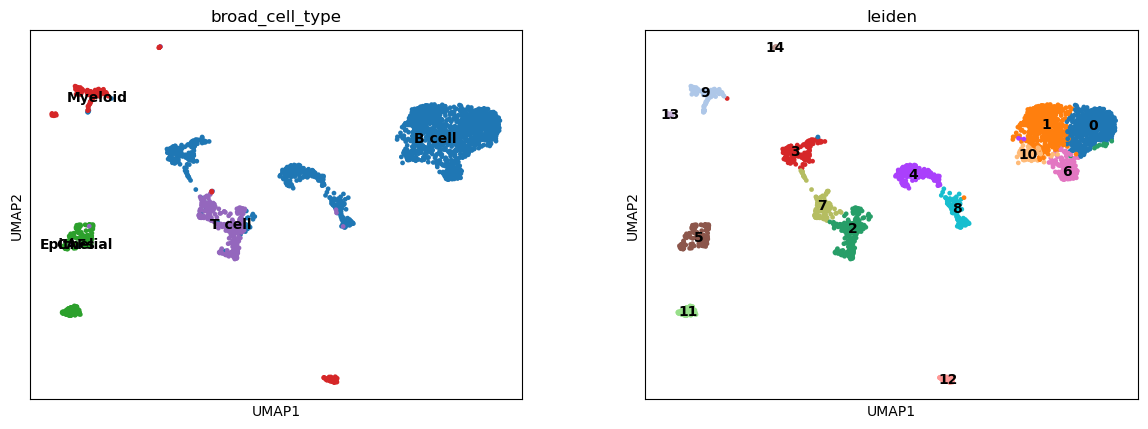

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: B cell, CAFs, Epithelial, etc.
var_group_labels: chr1, chr2, chr3, etc.


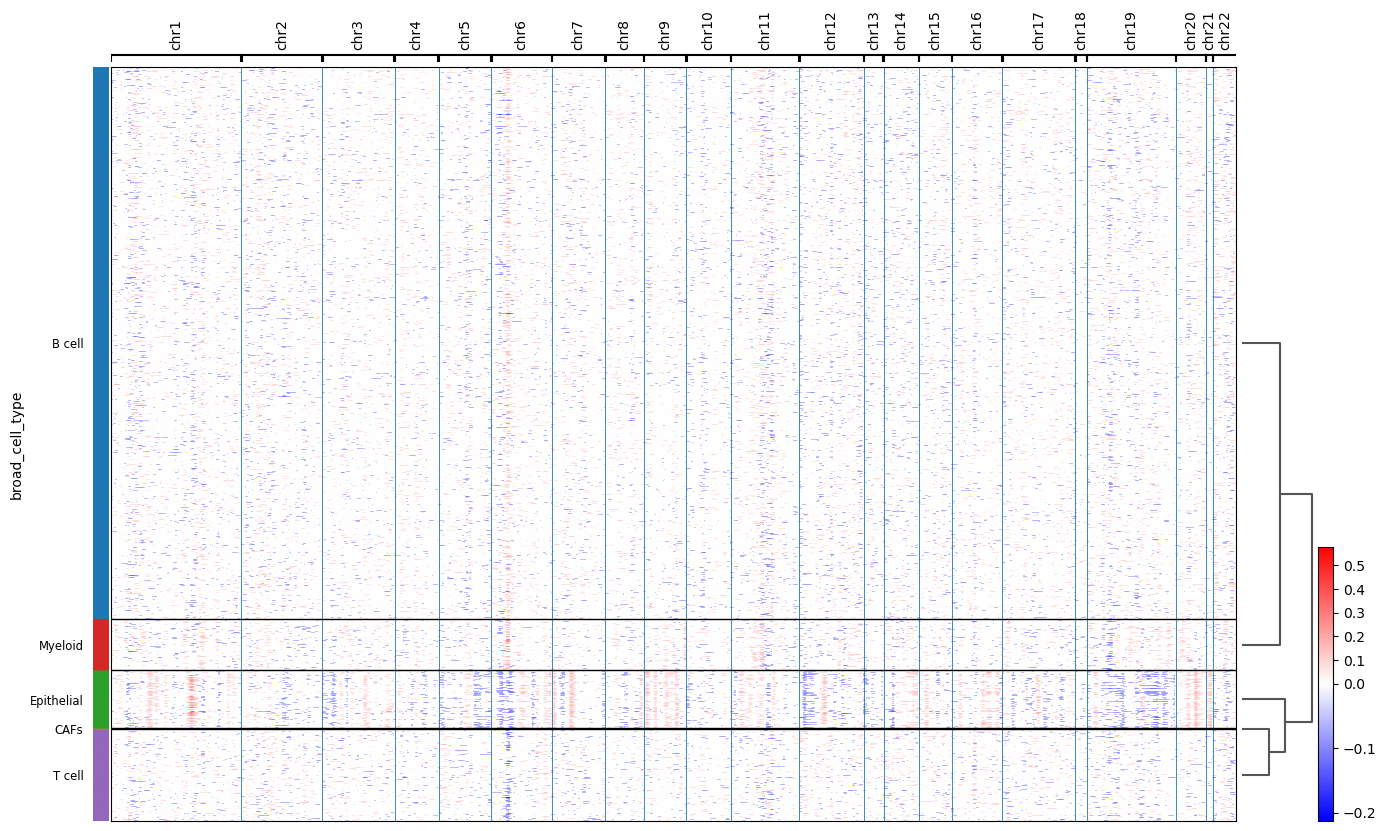

categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


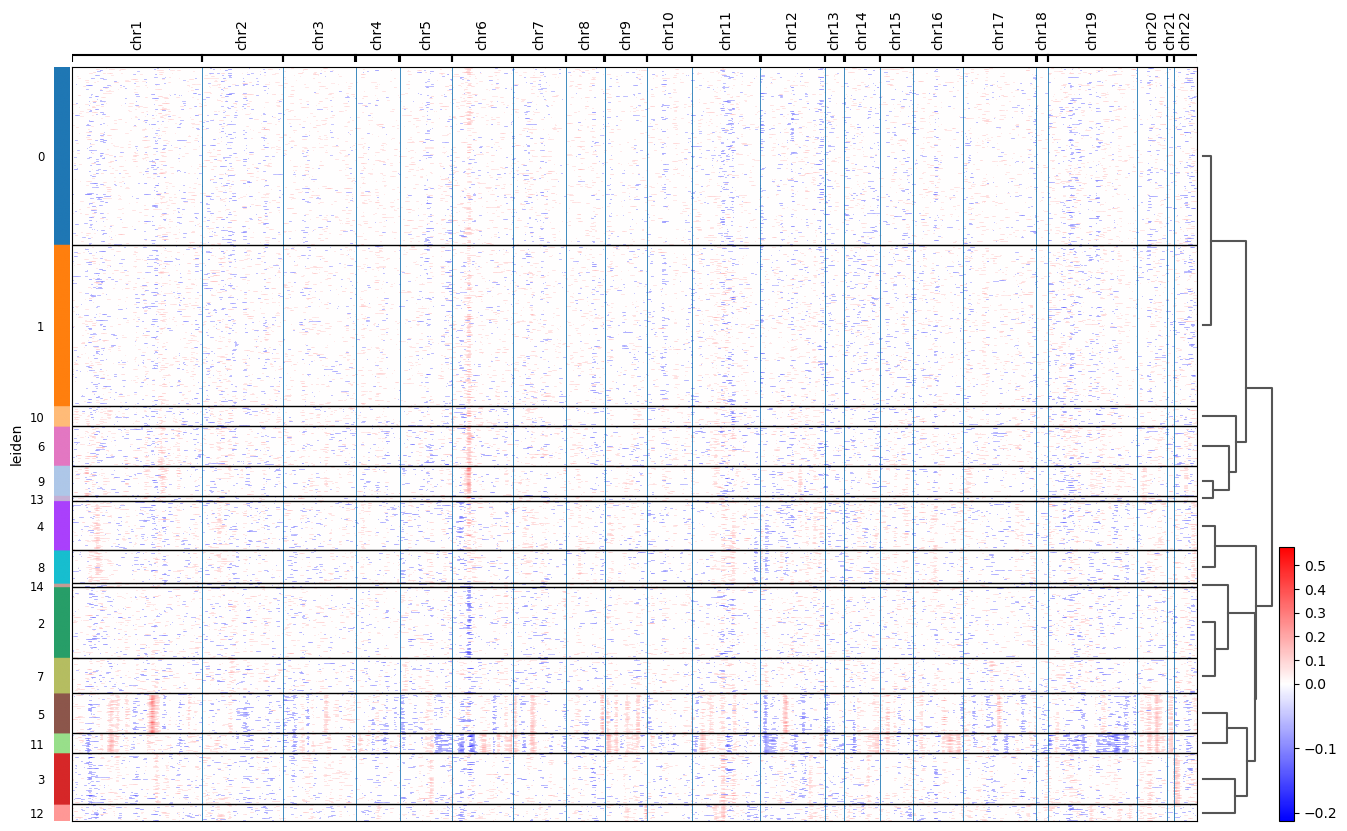

=== [N01.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_processed/N01.raw.processed.h5ad (30.7 MB) ===

=== [P03.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_raw/P03.raw.h5ad ===

=== [P03.raw] running pca_to_cnv_per_sample_pipe ===
[steps] 01/03 PCAStep: start
[steps] 01/03 PCAStep: done (0.38s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (14.72s)
[steps] 03/03 infercnv: start
[GTF] Using cached GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Reading GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Positions added. Missing genes: 7703/24720


  0%|          | 0/2 [00:00<?, ?it/s]/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
100%|██████████| 2/2 [00:04<00:00,  2.49s/it]


[steps] 03/03 infercnv: done (12.96s)
AnnData object with n_obs × n_vars = 6135 × 24720
    obs: 'cell_id', 'cell_type', 'sample', 'broad_cell_type', 'sample_id', 'batch', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'scrna_pipeline', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'cnv'
    obsm: 'X_pca', 'X_umap', 'X_cnv'
    layers: 'log1p'
    obsp: 'distances', 'connectivities'

### Sample: P03.raw


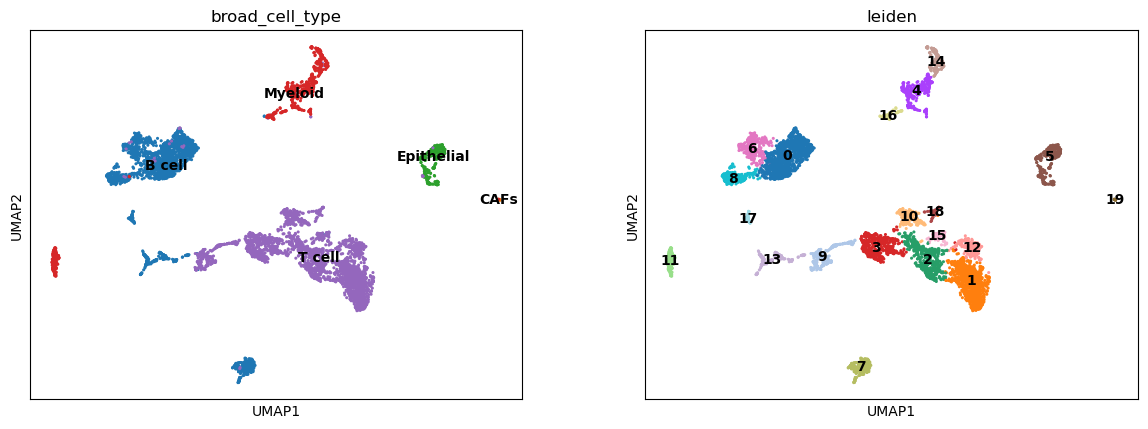

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: B cell, CAFs, Epithelial, etc.
var_group_labels: chr1, chr2, chr3, etc.


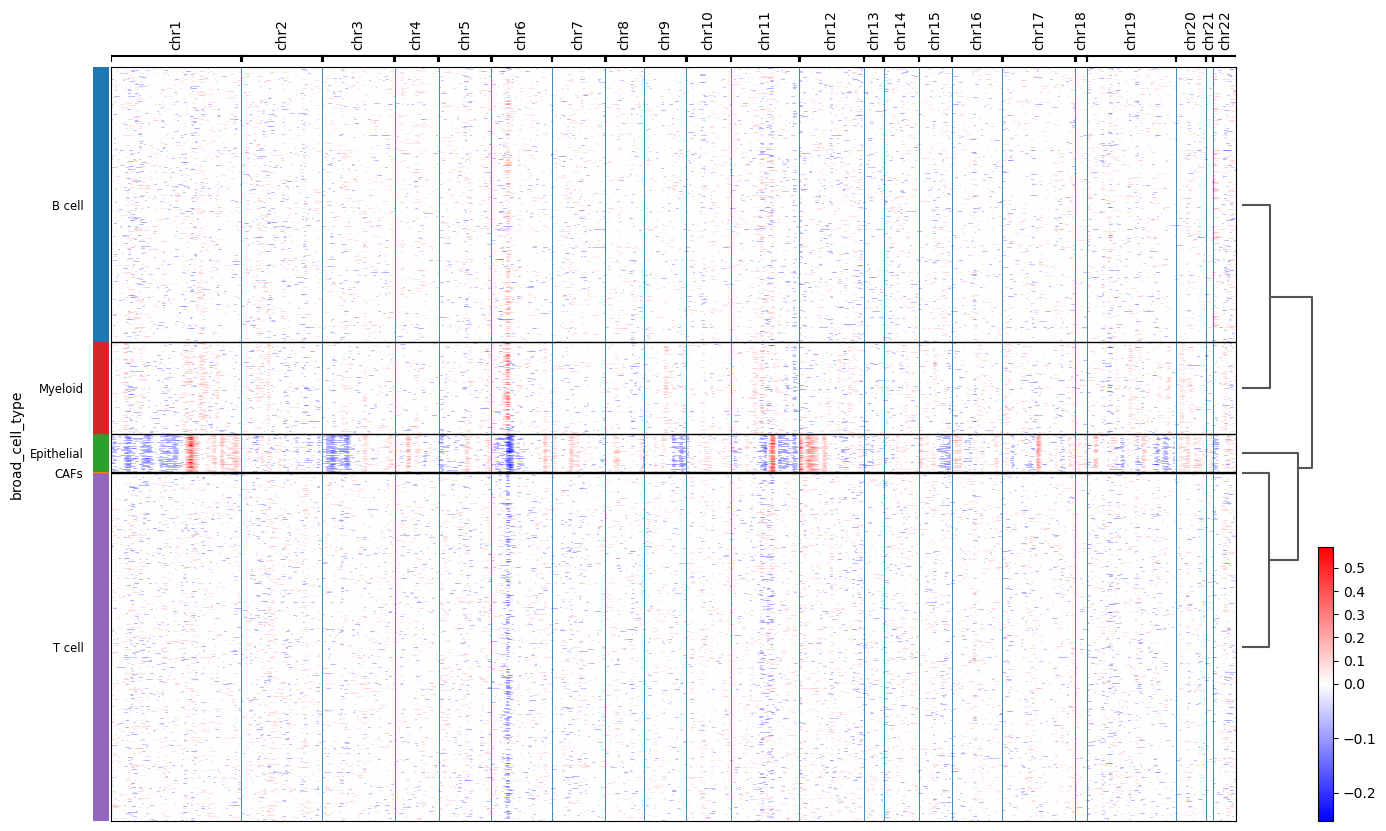

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


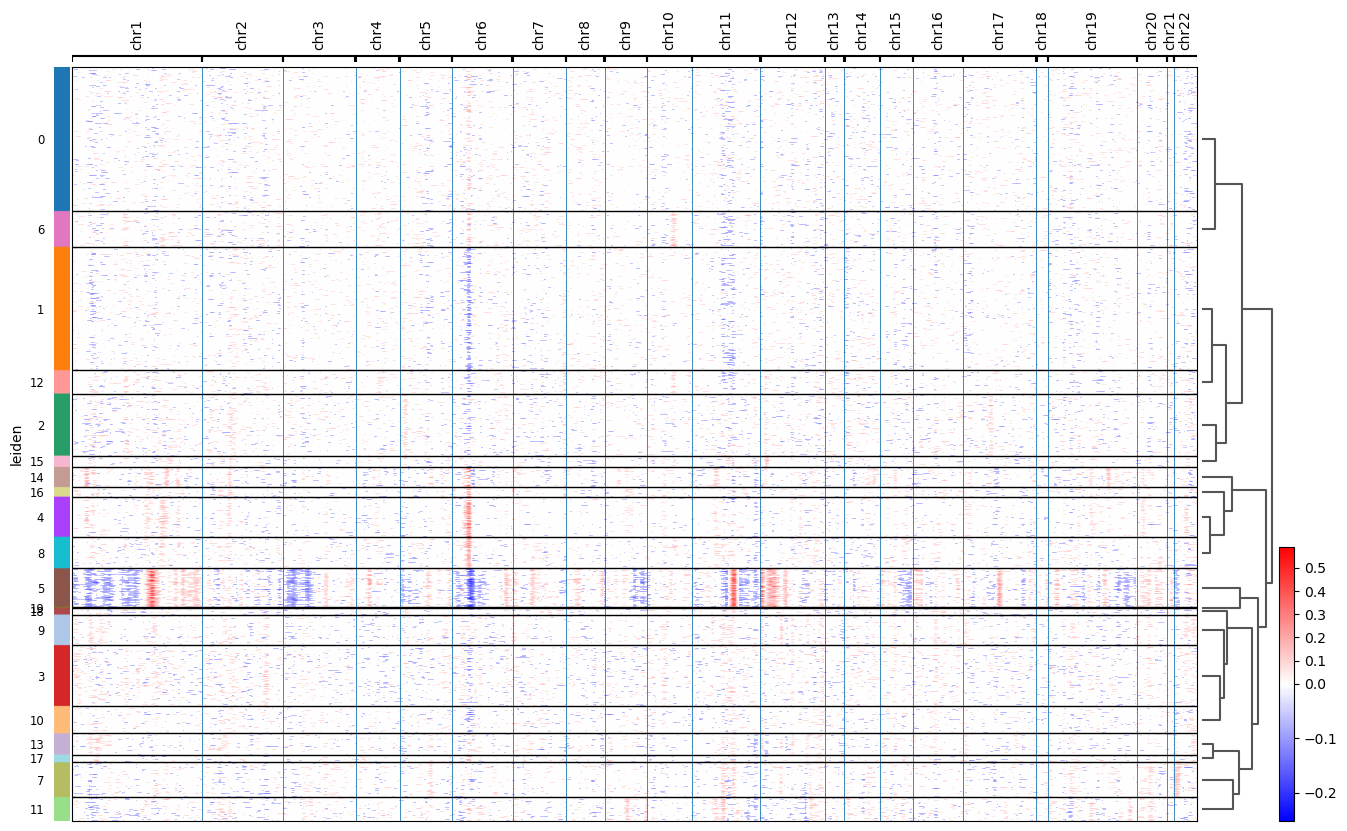

=== [P03.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_processed/P03.raw.processed.h5ad (72.2 MB) ===


In [6]:
from scrna_pipeline.core.pipeline import StepSpec

from scrna_pipeline.steps.preprocessing import BuildEmbeddingPCAStep
from scrna_pipeline.steps.infercnv import InferCNVStep
from scrna_pipeline.steps.clustering import ClusterAndEmbedStep
from pathlib import Path


from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)

# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs

})



def pca_to_cnv_per_sample_pipe(batch_key):
    steps: list[StepSpec] = [
        StepSpec(
            name="PCAStep",
            step=BuildEmbeddingPCAStep(batch_key=batch_key)),
        StepSpec(
            name="cluster_and_embed",
            step=ClusterAndEmbedStep(
            ),
            mode="required",
            on_error="raise",
        ),
        StepSpec(
            name="infercnv",
            step=InferCNVStep(
                    reference_key='broad_cell_type',
                    reference_categories=["T cell","B cell"],
                    layer='log1p',
                    require_log1p=True,
                ),
        )
    

    ]
    return steps

cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_some_raw",
    pipeline=pca_to_cnv_per_sample_pipe,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=False,   # deletes raw only after successful save
    on_sample_done=on_sample_done_plot_umap_drop_history,  # or None
)


# calling tumor vs normal

In [241]:
adata = sc.read_h5ad('/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/per_sample_processed/P03.raw.processed.h5ad')

print(adata)

AnnData object with n_obs × n_vars = 6135 × 24720
    obs: 'cell_id', 'cell_type', 'sample', 'broad_cell_type', 'sample_id', 'batch', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'broad_cell_type_colors', 'cnv', 'dendrogram_broad_cell_type', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'pca', 'scrna_pipeline', 'umap'
    obsm: 'X_cnv', 'X_pca', 'X_umap'
    layers: 'log1p'


In [242]:
X = adata.obsm["X_cnv"]
print(type(X))
print(getattr(X, "shape", None))
print(np.asarray(X).ndim, np.asarray(X).dtype)


<class 'scipy.sparse._csr.csr_matrix'>
(6135, 1431)
0 object


In [270]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.mixture import GaussianMixture
from anndata import AnnData


def call_tumor_like_epithelial_from_infercnv(
    adata: AnnData,
    *,
    broad_key: str = "broad_cell_type",
    epi_label: str = "Epithelial",
    cnv_key: str = "X_cnv",
    min_epi_cells: int = 200,
    use_2d: bool = True,
    bic_margin: float = 20.0,
    min_mean_gap: float = 0.02,
    tumor_p_thresh: float = 0.90,
    random_state: int = 0,
) -> pd.DataFrame:
    """
    Infer tumor-like epithelial cells using inferCNV output.

    Uses a principled 1-vs-2 component mixture model on CNV amplitude
    (optionally + CNV smoothness) within epithelial cells only.

    Adds to adata.obs:
      - cnv_amp
      - cnv_smooth
      - p_tumor_cnv
      - tumor_like_cnv

    Returns
    -------
    report : pd.DataFrame (single row)
        Diagnostic summary for this sample.
    """

    # ----------------------------
    # Checks
    # ----------------------------
    if cnv_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{cnv_key}'] not found")

    if broad_key not in adata.obs:
        raise KeyError(f"adata.obs['{broad_key}'] not found")

    epi_mask = adata.obs[broad_key].astype(str).values == epi_label
    n_epi = int(epi_mask.sum())

    # Initialize outputs (safe defaults)
    adata.obs["cnv_amp"] = np.nan
    adata.obs["cnv_smooth"] = np.nan
    adata.obs["p_tumor_cnv"] = 0.0
    adata.obs["tumor_like_cnv"] = False

    if n_epi < min_epi_cells:
        return pd.DataFrame([{
            "n_epi": n_epi,
            "model": "skipped",
            "reason": f"n_epi < {min_epi_cells}",
        }])

    # ----------------------------
    # Load CNV matrix safely
    # ----------------------------
    X = adata.obsm[cnv_key]

    if sp.issparse(X):
        X = X.toarray()          # (cells × cnv_features)
    else:
        X = np.asarray(X)

    if X.ndim != 2:
        raise ValueError(
            f"{cnv_key} must be 2D (cells × features). Got shape={X.shape}"
        )

    # ----------------------------
    # Per-cell CNV features
    # ----------------------------
    cnv_amp = np.mean(np.abs(X), axis=1)

    if use_2d and X.shape[1] > 1:
        # Smoothness = contiguous CNVs → smaller adjacent diffs
        cnv_smooth = -np.mean(np.abs(np.diff(X, axis=1)), axis=1)
    else:
        cnv_smooth = np.full(X.shape[0], np.nan)
        use_2d = False

    adata.obs["cnv_amp"] = cnv_amp
    adata.obs["cnv_smooth"] = cnv_smooth

    # ----------------------------
    # Fit mixture on epithelial only
    # ----------------------------
    amp_e = cnv_amp[epi_mask]
    smooth_e = cnv_smooth[epi_mask]

    if use_2d:
        feats = np.column_stack([amp_e, smooth_e])
    else:
        feats = amp_e.reshape(-1, 1)

    g1 = GaussianMixture(
        n_components=1,
        covariance_type="full",
        random_state=random_state,
    ).fit(feats)

    g2 = GaussianMixture(
        n_components=2,
        covariance_type="full",
        random_state=random_state,
    ).fit(feats)

    bic1 = g1.bic(feats)
    bic2 = g2.bic(feats)
    bic_improvement = bic1 - bic2

    report = {
        "n_epi": n_epi,
        "bic_1comp": float(bic1),
        "bic_2comp": float(bic2),
        "bic_improvement": float(bic_improvement),
        "model": "1comp",
        "mean_gap": np.nan,
        "tumor_component": np.nan,
        "n_tumor_like": 0,
        "tumor_frac_epi": 0.0,
    }

    # ----------------------------
    # Decide whether to accept 2 components
    # ----------------------------
    if bic_improvement >= bic_margin:
        if use_2d:
            means = g2.means_[:, 0]   # compare on cnv_amp dimension
        else:
            means = g2.means_.ravel()

        tumor_k = int(np.argmax(means))
        normal_k = 1 - tumor_k
        mean_gap = float(means[tumor_k] - means[normal_k])

        report["mean_gap"] = mean_gap
        report["tumor_component"] = tumor_k

        if mean_gap >= min_mean_gap:
            post = g2.predict_proba(feats)[:, tumor_k]
            adata.obs.loc[epi_mask, "p_tumor_cnv"] = post
            report["model"] = "2comp"
        else:
            report["model"] = "1comp_forced (gap too small)"

    # ----------------------------
    # Final tumor-like call
    # ----------------------------
    adata.obs["tumor_like_cnv"] = adata.obs["p_tumor_cnv"].values >= tumor_p_thresh

    n_tumor = int((adata.obs["tumor_like_cnv"].values & epi_mask).sum())
    report["n_tumor_like"] = n_tumor
    report["tumor_frac_epi"] = float(n_tumor / max(n_epi, 1))

    return pd.DataFrame([report])


In [271]:
rep = call_tumor_like_epithelial_from_infercnv(
    adata,
    epi_label="Epithelial",
    use_2d=False,
    bic_margin=5.0,      # relax just to see if there is weak bimodality
    min_mean_gap=0.01,
    tumor_p_thresh=0.90,
)
rep



,n_epi,bic_1comp,bic_2comp,bic_improvement,model,mean_gap,tumor_component,n_tumor_like,tumor_frac_epi
0,307,-2204.636725,-2218.674751,14.038026,2comp,0.010019,0,148,0.482085


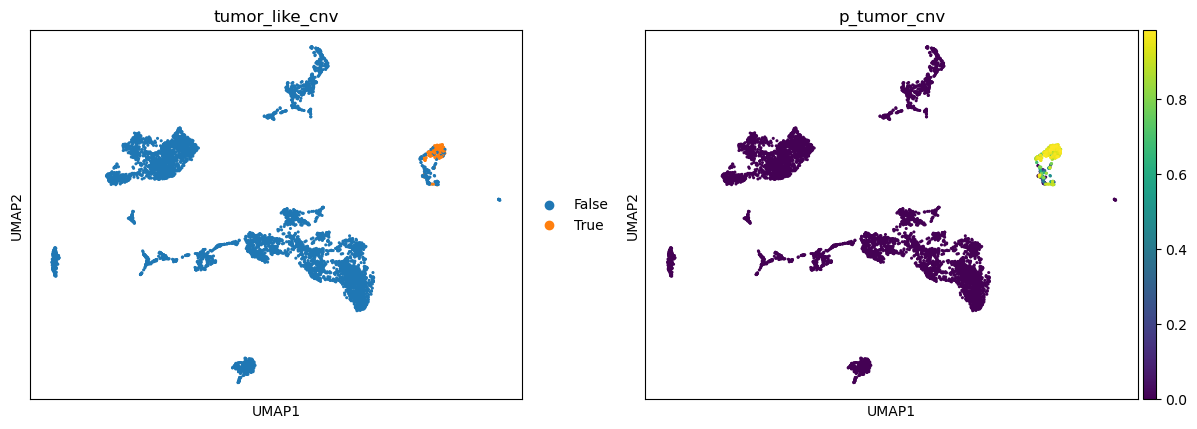

In [274]:
sc.pl.umap(adata, color=['tumor_like_cnv','p_tumor_cnv'])

In [254]:
adata.obs["CNV_high_epi"] = False

epi = adata.obs["broad_cell_type"] == "Epithelial"
adata.obs.loc[epi & (adata.obs["p_tumor_cnv"] >= 0.9), "CNV_high_epi"] = True


In [255]:
adata.obs["CNV_high_epi"].value_counts()


CNV_high_epi
False    5987
True      148
Name: count, dtype: int64

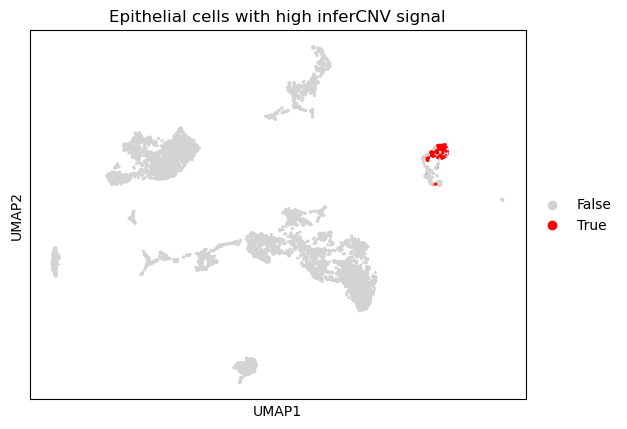

In [257]:
import scanpy as sc

sc.pl.umap(
    adata,
    color="CNV_high_epi",
    palette={"True": "red", "False": "lightgrey"},
    size=20,
    title="Epithelial cells with high inferCNV signal",
)



In [263]:
from __future__ import annotations

from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from anndata import AnnData


def _as_dense(X) -> np.ndarray:
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)


def _try_get_cnv_columns_df(adata: AnnData, *, cnv_uns_key: str = "cnv") -> Optional[pd.DataFrame]:
    """
    Try to retrieve a dataframe describing CNV columns (bins/segments) with at least:
      - chromosome (or chr)
      - start
    Returns None if not found.
    """
    if cnv_uns_key not in adata.uns:
        return None

    u = adata.uns[cnv_uns_key]
    # common patterns across versions/wrappers
    candidate_keys = ["bins", "bin_df", "cnv_bins", "var", "cnv_var", "cnv_features", "features"]
    for k in candidate_keys:
        if k in u:
            obj = u[k]
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                # normalize column names
                cols = {c.lower(): c for c in df.columns}
                chr_col = cols.get("chromosome") or cols.get("chr") or cols.get("chrom")
                start_col = cols.get("start")
                if chr_col and start_col:
                    out = df.rename(columns={chr_col: "chromosome", start_col: "start"})
                    # optional end
                    end_col = cols.get("end")
                    if end_col:
                        out = out.rename(columns={end_col: "end"})
                    return out[["chromosome", "start"] + (["end"] if "end" in out.columns else [])]
            # sometimes stored as dict-like arrays
    # alternative: separate arrays
    if isinstance(u, dict):
        keys_lower = {str(k).lower(): k for k in u.keys()}
        chr_k = keys_lower.get("chromosome") or keys_lower.get("chr")
        start_k = keys_lower.get("start")
        if chr_k and start_k:
            chr_arr = np.asarray(u[chr_k])
            start_arr = np.asarray(u[start_k])
            if chr_arr.ndim == 1 and start_arr.ndim == 1 and chr_arr.shape[0] == start_arr.shape[0]:
                return pd.DataFrame({"chromosome": chr_arr.astype(str), "start": start_arr.astype(float)})

    return None


def plot_infercnv_heatmap_two_epi_groups(
    adata: AnnData,
    *,
    broad_key: str = "broad_cell_type",
    epi_label: str = "Epithelial",
    p_key: str = "p_tumor_cnv",
    high_thresh: float = 0.90,
    cnv_obsm_key: str = "X_cnv",
    cnv_uns_key: str = "cnv",
    # plotting
    vmin: float = -0.5,
    vmax: float = 0.5,
    cmap: str = "RdBu_r",
    figsize: Tuple[float, float] = (16, 6),
    show_mean_profiles: bool = True,
    show_chr_boundaries: bool = True,
    boundary_lw: float = 0.5,
    boundary_alpha: float = 0.5,
    title: str = "inferCNV heatmaps: Epithelial CNV-high vs CNV-low",
) -> Dict[str, Any]:
    """
    Plot inferCNV-style chromosome heatmaps for two epithelial groups:
      - CNV-high epithelial cells: p_key >= high_thresh
      - CNV-low epithelial cells:  p_key <  high_thresh

    IMPORTANT:
    `adata.obsm[cnv_obsm_key]` often has CNV bins/features (not genes), so we attempt to
    read bin genomic coordinates from `adata.uns[cnv_uns_key]` to order columns.

    If coordinates cannot be found, columns are plotted in their existing order.
    """
    # --- checks ---
    if cnv_obsm_key not in adata.obsm:
        raise KeyError(f"{cnv_obsm_key!r} not found in adata.obsm. Available: {list(adata.obsm.keys())}")
    if p_key not in adata.obs:
        raise KeyError(f"{p_key!r} not found in adata.obs. Available: {list(adata.obs.columns)}")
    if broad_key not in adata.obs:
        raise KeyError(f"{broad_key!r} not found in adata.obs. Available: {list(adata.obs.columns)}")

    epi_mask = (adata.obs[broad_key].astype(str) == str(epi_label)).to_numpy()
    p = adata.obs[p_key].to_numpy()

    hi_mask = epi_mask & (p >= high_thresh)
    lo_mask = epi_mask & (p < high_thresh)

    n_epi = int(epi_mask.sum())
    n_hi = int(hi_mask.sum())
    n_lo = int(lo_mask.sum())
    if n_hi == 0 or n_lo == 0:
        raise ValueError(f"After thresholding: n_hi={n_hi}, n_lo={n_lo}. Adjust high_thresh or check p_key.")

    # --- extract CNV matrix ---
    X = _as_dense(adata.obsm[cnv_obsm_key])
    if X.ndim != 2:
        raise ValueError(f"{cnv_obsm_key} must be 2D; got shape {X.shape}")

    # --- order CNV columns using uns['cnv'] bin coordinates if available ---
    cnv_df = _try_get_cnv_columns_df(adata, cnv_uns_key=cnv_uns_key)
    col_idx = np.arange(X.shape[1])
    boundaries = np.array([], dtype=int)

    if cnv_df is not None and len(cnv_df) == X.shape[1]:
        df = cnv_df.copy()
        df["chromosome"] = df["chromosome"].astype(str)

        # simple chromosome ordering: lexicographic (fine for diagnostics)
        df["_chr"] = df["chromosome"]

        order = df.sort_values(["_chr", "start"]).index.to_numpy()
        col_idx = order.astype(int)

        chr_vec = df.loc[col_idx, "chromosome"].to_numpy()
        boundaries = np.where(chr_vec[1:] != chr_vec[:-1])[0]
        used_ordering = True
    else:
        used_ordering = False

    X_hi = X[hi_mask][:, col_idx]
    X_lo = X[lo_mask][:, col_idx]

    mean_hi = X_hi.mean(axis=0)
    mean_lo = X_lo.mean(axis=0)

    # --- plot ---
    if show_mean_profiles:
        fig, axes = plt.subplots(
            2, 2,
            figsize=(figsize[0], figsize[1] + 2),
            gridspec_kw={"height_ratios": [3, 1]}
        )
        ax_hm_hi, ax_hm_lo = axes[0]
        ax_mean_hi, ax_mean_lo = axes[1]
    else:
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        ax_hm_hi, ax_hm_lo = axes
        ax_mean_hi = ax_mean_lo = None

    im1 = ax_hm_hi.imshow(X_hi, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax_hm_hi.set_title(f"CNV-high epi (p≥{high_thresh})  n={n_hi}")
    ax_hm_hi.set_ylabel("cells")
    ax_hm_hi.set_xlabel("CNV bins (genomic order)" if used_ordering else "CNV bins (native order)")

    im2 = ax_hm_lo.imshow(X_lo, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax_hm_lo.set_title(f"CNV-low epi (p<{high_thresh})  n={n_lo}")
    ax_hm_lo.set_ylabel("cells")
    ax_hm_lo.set_xlabel("CNV bins (genomic order)" if used_ordering else "CNV bins (native order)")

    cbar = fig.colorbar(im2, ax=[ax_hm_hi, ax_hm_lo], fraction=0.02, pad=0.02)
    cbar.set_label("inferCNV signal")

    if show_mean_profiles:
        ax_mean_hi.plot(mean_hi, linewidth=1)
        ax_mean_hi.axhline(0, linewidth=0.5, linestyle="--")
        ax_mean_hi.set_title("Mean profile (CNV-high epi)")
        ax_mean_hi.set_xlabel("CNV bins")
        ax_mean_hi.set_ylabel("mean")

        ax_mean_lo.plot(mean_lo, linewidth=1)
        ax_mean_lo.axhline(0, linewidth=0.5, linestyle="--")
        ax_mean_lo.set_title("Mean profile (CNV-low epi)")
        ax_mean_lo.set_xlabel("CNV bins")
        ax_mean_lo.set_ylabel("mean")

        if show_chr_boundaries and used_ordering and boundaries.size > 0:
            for b in boundaries:
                ax_mean_hi.axvline(b, linewidth=boundary_lw, alpha=boundary_alpha)
                ax_mean_lo.axvline(b, linewidth=boundary_lw, alpha=boundary_alpha)

    fig.suptitle(f"{title} (epi={n_epi})", y=1.02)
    fig.tight_layout()
    plt.show()

    return {
        "n_epi": n_epi,
        "n_hi": n_hi,
        "n_lo": n_lo,
        "hi_mask": hi_mask,
        "lo_mask": lo_mask,
        "used_genomic_ordering": used_ordering,
        "chr_boundaries": boundaries,
        "mean_hi": mean_hi,
        "mean_lo": mean_lo,
        "cnv_columns_df_found": cnv_df is not None,
        "cnv_columns_df_len": None if cnv_df is None else len(cnv_df),
        "X_shape": X.shape,
    }


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_49041/1473828503.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


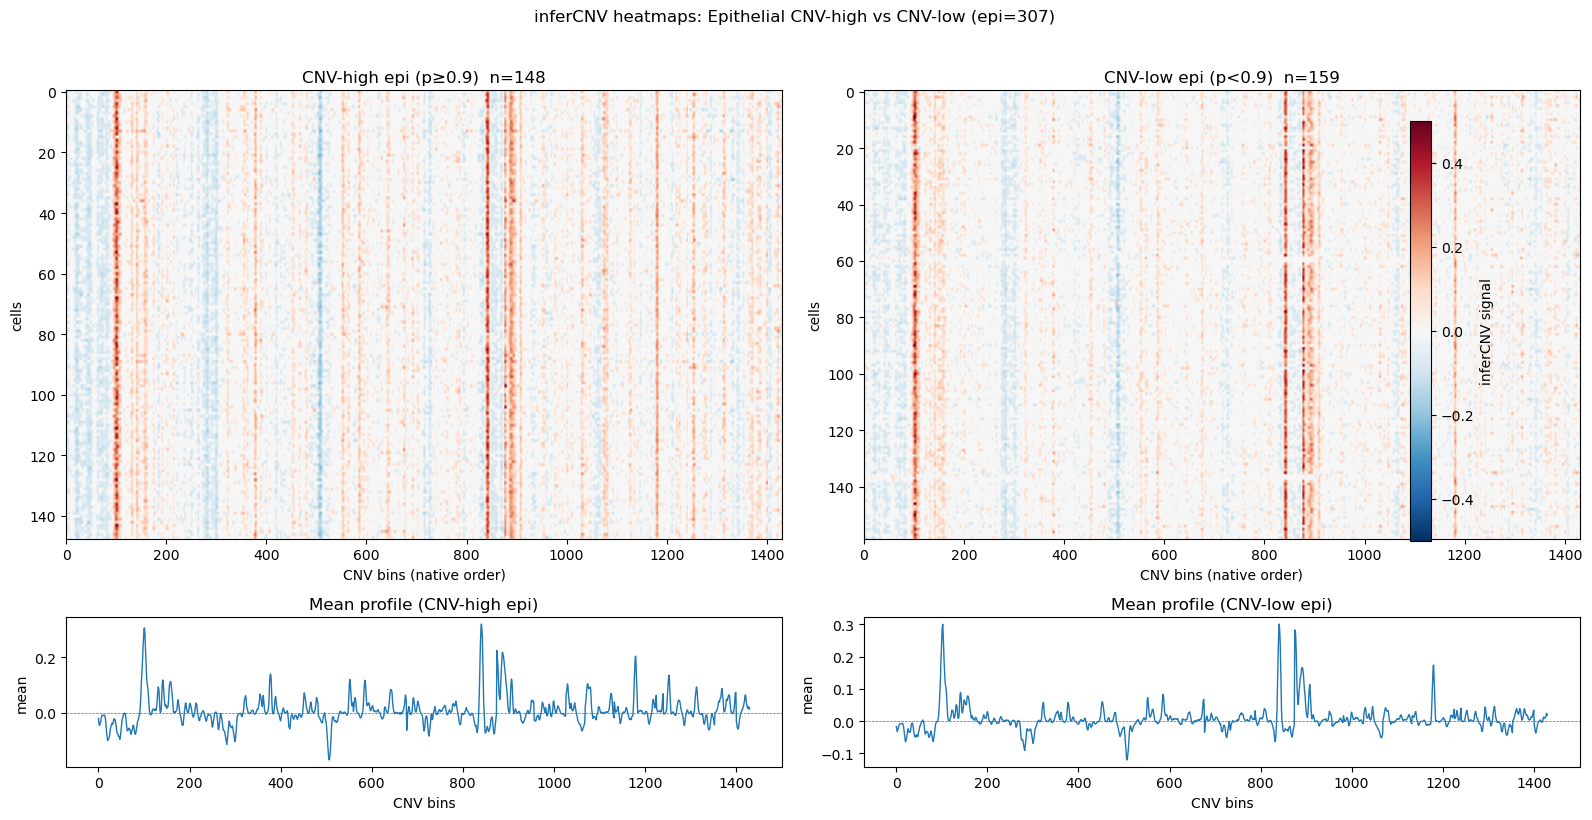

In [265]:
out = plot_infercnv_heatmap_two_epi_groups(
    adata,
    broad_key="broad_cell_type",
    epi_label="Epithelial",
    p_key="p_tumor_cnv",
    high_thresh=0.90,
    cnv_obsm_key="X_cnv",
    cnv_uns_key="cnv",
    show_mean_profiles=True,
)


In [268]:
from __future__ import annotations

from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scanpy as sc
from anndata import AnnData


def _as_dense(X) -> np.ndarray:
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)


def _try_get_cnv_bins_df(adata: AnnData, *, cnv_uns_key: str = "cnv") -> Optional[pd.DataFrame]:
    if cnv_uns_key not in adata.uns:
        return None
    u = adata.uns[cnv_uns_key]
    if not isinstance(u, dict):
        return None

    for k in ["bins", "bin_df", "cnv_bins", "cnv_var", "var", "features"]:
        if k in u and isinstance(u[k], pd.DataFrame):
            df = u[k].copy()
            cols = {c.lower(): c for c in df.columns}
            chr_col = cols.get("chromosome") or cols.get("chr") or cols.get("chrom")
            start_col = cols.get("start")
            if chr_col and start_col:
                out = df.rename(columns={chr_col: "chromosome", start_col: "start"})
                keep = ["chromosome", "start"]
                if "end" in cols:
                    out = out.rename(columns={cols["end"]: "end"})
                    keep.append("end")
                return out[keep]

    keys_lower = {str(k).lower(): k for k in u.keys()}
    chr_k = keys_lower.get("chromosome") or keys_lower.get("chr")
    start_k = keys_lower.get("start")
    if chr_k and start_k:
        chr_arr = np.asarray(u[chr_k]).astype(str)
        start_arr = np.asarray(u[start_k])
        if chr_arr.ndim == 1 and start_arr.ndim == 1 and chr_arr.shape[0] == start_arr.shape[0]:
            return pd.DataFrame({"chromosome": chr_arr, "start": start_arr})

    return None


def cnv_leiden_umap_and_chrom_heatmap(
    adata: AnnData,
    *,
    broad_key: str = "broad_cell_type",
    epi_label: str = "Epithelial",
    p_key: str = "p_tumor_cnv",
    high_thresh: float = 0.90,
    cnv_obsm_key: str = "X_cnv",
    cnv_uns_key: str = "cnv",
    n_neighbors: int = 15,
    metric: str = "euclidean",
    resolution: float = 0.6,
    random_state: int = 0,
    leiden_key: str = "cnv_leiden",
    # plotting
    vmin: float = -0.5,
    vmax: float = 0.5,
    cmap: str = "RdBu_r",
    heatmap_figsize: Tuple[float, float] = (16, 7),
    umap_size: int = 20,
    show_chr_boundaries: bool = True,
) -> Dict[str, Any]:
    """
    CNV-based Leiden on epithelial cells + UMAP + inferCNV-style chromosome heatmap,
    with your "148 cells" highlighted.
    """

    # ---- checks ----
    for k in [cnv_obsm_key]:
        if k not in adata.obsm:
            raise KeyError(f"{k!r} not found in adata.obsm")
    for k in [broad_key, p_key]:
        if k not in adata.obs:
            raise KeyError(f"{k!r} not found in adata.obs")

    # ---- subset epithelium ----
    epi_mask = (adata.obs[broad_key].astype(str) == str(epi_label)).to_numpy()
    ad_epi = adata[epi_mask].copy()

    # ---- CNV-high mask (your ~148) ----
    p = ad_epi.obs[p_key].to_numpy()
    cnv_high = p >= high_thresh
    ad_epi.obs["CNV_high_epi_cat"] = pd.Categorical(
        np.where(cnv_high, "CNV_high", "CNV_low"),
        categories=["CNV_low", "CNV_high"],
        ordered=True,
    )

    # ---- compute CNV graph + leiden + umap ----
    X = _as_dense(ad_epi.obsm[cnv_obsm_key])
    ad_epi.obsm[cnv_obsm_key] = X  # store dense

    sc.pp.neighbors(ad_epi, use_rep=cnv_obsm_key, n_neighbors=n_neighbors, metric=metric, random_state=random_state)
    sc.tl.leiden(ad_epi, resolution=resolution, key_added=leiden_key, random_state=random_state)
    sc.tl.umap(ad_epi, random_state=random_state)

    # ---- UMAP plots (NO palette collisions) ----
    sc.pl.umap(ad_epi, color=leiden_key, size=umap_size,
               title=f"CNV-based Leiden on epithelium ({leiden_key})")

    sc.pl.umap(
        ad_epi,
        color="CNV_high_epi_cat",
        palette={"CNV_low": "lightgrey", "CNV_high": "red"},
        size=umap_size,
        title=f"Epithelial CNV-high (p≥{high_thresh})",
    )

    # ---- column ordering for heatmap ----
    bins_df = _try_get_cnv_bins_df(ad_epi, cnv_uns_key=cnv_uns_key)
    col_idx = np.arange(X.shape[1])
    chr_boundaries = np.array([], dtype=int)
    used_genomic_ordering = False

    if bins_df is not None and len(bins_df) == X.shape[1]:
        df = bins_df.copy()
        df["chromosome"] = df["chromosome"].astype(str)
        df["_chr"] = df["chromosome"]  # lexicographic
        col_idx = df.sort_values(["_chr", "start"]).index.to_numpy().astype(int)
        used_genomic_ordering = True

        chr_vec = df.loc[col_idx, "chromosome"].to_numpy()
        chr_boundaries = np.where(chr_vec[1:] != chr_vec[:-1])[0]

    X_ord = X[:, col_idx]

    # ---- order rows by cnv_leiden, then cnv_high, then p ----
    leiden = ad_epi.obs[leiden_key].astype(str).to_numpy()
    sort_df = pd.DataFrame({"leiden": leiden, "cnv_high": cnv_high.astype(int), "p": p, "i": np.arange(ad_epi.n_obs)})
    sort_df = sort_df.sort_values(["leiden", "cnv_high", "p"], ascending=[True, False, False])
    row_idx = sort_df["i"].to_numpy()

    X_plot = X_ord[row_idx, :]
    high_plot = cnv_high[row_idx]
    leiden_plot = leiden[row_idx]

    # row boundaries between clusters
    row_boundaries = np.where(leiden_plot[1:] != leiden_plot[:-1])[0]

    # ---- plot heatmap with CNV-high markers ----
    fig = plt.figure(figsize=heatmap_figsize)
    ax = fig.add_subplot(111)
    im = ax.imshow(X_plot, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    for rb in row_boundaries:
        ax.axhline(rb + 0.5, linewidth=0.6, alpha=0.6)

    y_hi = np.where(high_plot)[0]
    if y_hi.size > 0:
        ax.scatter(
            np.full_like(y_hi, -5),
            y_hi,
            s=8,
            c="red",
            marker="s",
            linewidths=0,
            alpha=0.9,
            clip_on=False,
            label=f"CNV-high (p≥{high_thresh})",
        )

    if used_genomic_ordering and show_chr_boundaries and chr_boundaries.size > 0:
        for b in chr_boundaries:
            ax.axvline(b + 0.5, linewidth=0.4, alpha=0.35)

    ax.set_title(
        "inferCNV-style chromosome heatmap (epithelium)\n"
        f"Rows ordered by {leiden_key} (then CNV-high, then p). "
        + ("Cols in genomic order." if used_genomic_ordering else "Cols in native X_cnv order.")
    )
    ax.set_xlabel("CNV bins")
    ax.set_ylabel("Epithelial cells (ordered)")

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label("inferCNV signal")
    ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()

    return {
        "ad_epi": ad_epi,
        "n_epi": int(epi_mask.sum()),
        "n_cnv_high_epi": int(cnv_high.sum()),
        "used_genomic_ordering": used_genomic_ordering,
        "chr_boundaries": chr_boundaries,
        "row_order": row_idx,
        "col_order": col_idx,
        "leiden_key": leiden_key,
    }


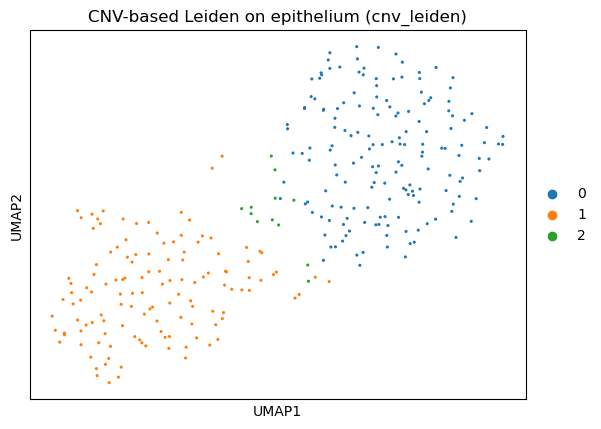

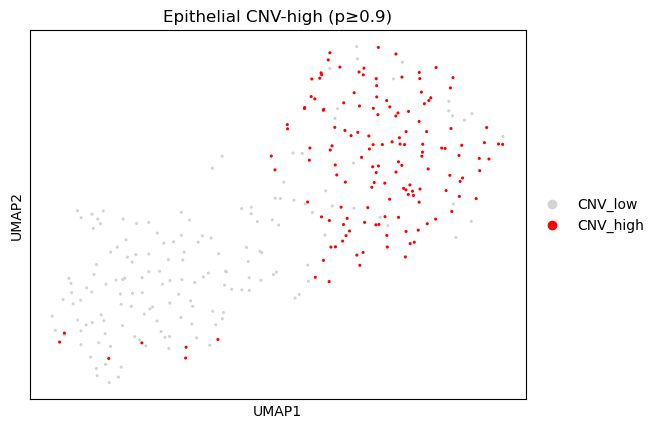

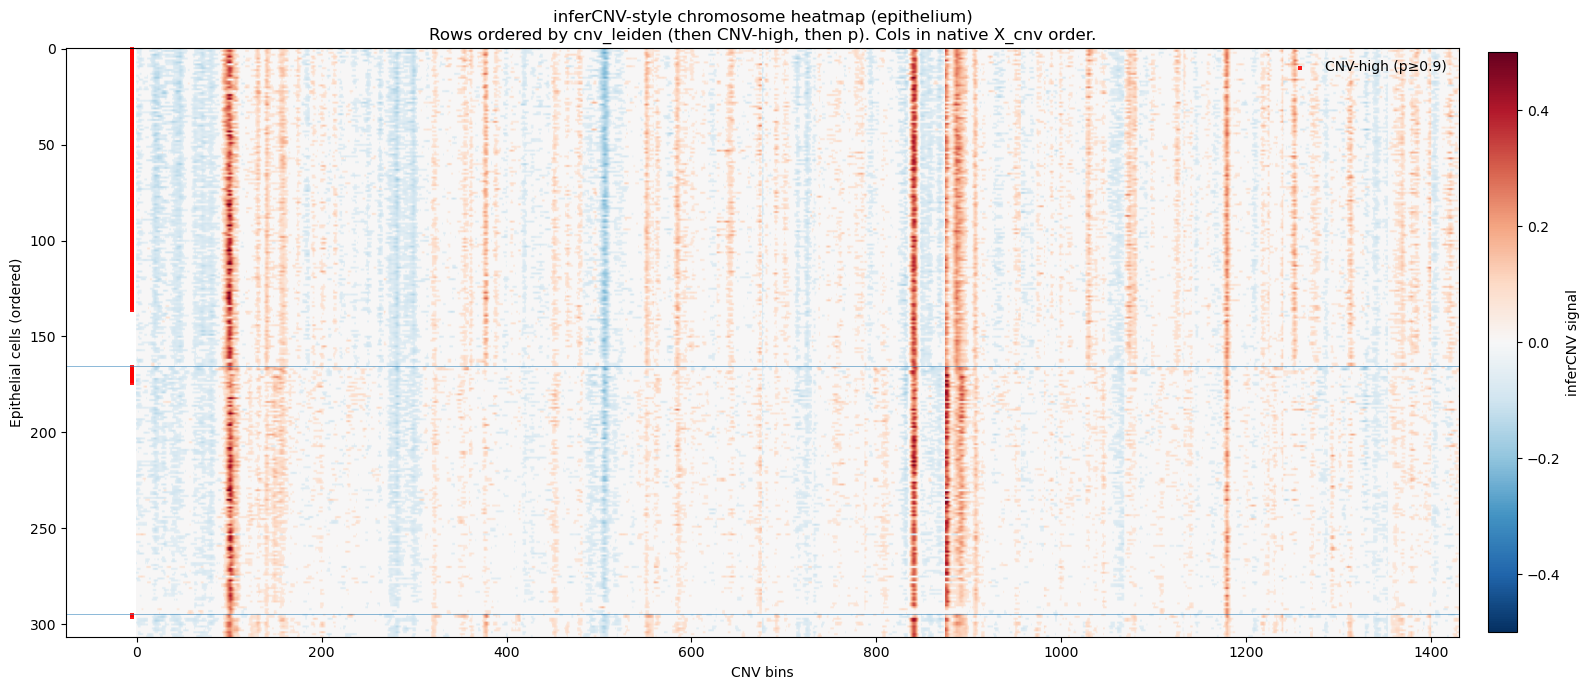

In [269]:
out = cnv_leiden_umap_and_chrom_heatmap(
    adata,
    broad_key="broad_cell_type",
    epi_label="Epithelial",
    p_key="p_tumor_cnv",
    high_thresh=0.90,
    cnv_obsm_key="X_cnv",
    cnv_uns_key="cnv",
    resolution=0.6,
    n_neighbors=15,
    leiden_key="cnv_leiden",
)


In [245]:
import numpy as np
import scipy.sparse as sp

epi = adata.obs["broad_cell_type"] == "Epithelial"
X = adata.obsm["X_cnv"]
X = X.toarray() if sp.issparse(X) else np.asarray(X)

cnv_smooth = -np.mean(np.abs(np.diff(X, axis=1)), axis=1)
adata.obs["cnv_smooth"] = cnv_smooth

hi = epi & (adata.obs["p_tumor_cnv"] >= 0.9)
lo = epi & (adata.obs["p_tumor_cnv"] <= 0.1)

print("smooth median hi:", float(np.median(adata.obs.loc[hi, "cnv_smooth"])))
print("smooth median lo:", float(np.median(adata.obs.loc[lo, "cnv_smooth"])))
print("n_hi, n_lo:", int(hi.sum()), int(lo.sum()))


smooth median hi: -0.011921638572383375
smooth median lo: -0.006602491306564536
n_hi, n_lo: 148 39


In [246]:
epi_mask = adata.obs["broad_cell_type"] == "Epithelial"

adata.obs.loc[epi_mask, "p_tumor_cnv"].describe()


count    307.000000
mean       0.707546
std        0.337734
min        0.000006
25%        0.510342
50%        0.889690
75%        0.954536
max        0.985113
Name: p_tumor_cnv, dtype: float64

In [247]:
(adata.obs["p_tumor_cnv"] >= 0.9).sum()

np.int64(148)

In [248]:
epi = adata.obs["broad_cell_type"] == "Epithelial"

print("epi cells:", epi.sum())
print("tumor_like_cnv TRUE (all cells):", int(adata.obs["tumor_like_cnv"].sum()))
print("tumor_like_cnv TRUE (epi only):", int((adata.obs["tumor_like_cnv"] & epi).sum()))

print("p_tumor_cnv >= 0.9 (all cells):", int((adata.obs["p_tumor_cnv"] >= 0.9).sum()))
print("p_tumor_cnv >= 0.9 (epi only):", int(((adata.obs["p_tumor_cnv"] >= 0.9) & epi).sum()))

print("p_tumor_cnv summary (epi):")
print(adata.obs.loc[epi, "p_tumor_cnv"].describe())


epi cells: 307
tumor_like_cnv TRUE (all cells): 148
tumor_like_cnv TRUE (epi only): 148
p_tumor_cnv >= 0.9 (all cells): 148
p_tumor_cnv >= 0.9 (epi only): 148
p_tumor_cnv summary (epi):
count    307.000000
mean       0.707546
std        0.337734
min        0.000006
25%        0.510342
50%        0.889690
75%        0.954536
max        0.985113
Name: p_tumor_cnv, dtype: float64


In [249]:
epi = adata[adata.obs["broad_cell_type"] == "Epithelial"].copy()

df = epi.obs.copy()
df["cnv_amp"] = epi.obs["cnv_amp"].values

cluster_key = "leiden"

cluster_stats = (
    df.groupby(cluster_key)["cnv_amp"]
      .agg(["median", "mean", "size"])
      .sort_values("median", ascending=False)
)

cluster_stats


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_49041/2047033509.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cluster_key)["cnv_amp"]


,median,mean,size
leiden,,,
5,0.030018,0.028843,307


In [250]:
epi = adata[adata.obs["broad_cell_type"] == "Epithelial"].copy()


In [251]:
import scanpy as sc

sc.pp.neighbors(epi, use_rep="X_pca", n_neighbors=15)
sc.tl.leiden(epi, resolution=0.5, key_added="leiden_epi")


In [252]:
df = epi.obs.copy()
df["cnv_amp"] = epi.obs["cnv_amp"].values

cluster_stats = (
    df.groupby("leiden_epi")["cnv_amp"]
      .agg(["median", "mean", "size"])
      .sort_values("median", ascending=False)
)

cluster_stats


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_49041/2493548354.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("leiden_epi")["cnv_amp"]


,median,mean,size
leiden_epi,,,
2,0.033232,0.033567,68
1,0.032708,0.032531,86
3,0.030015,0.029737,36
4,0.028110,0.025106,23
0,0.023215,0.022624,94


In [253]:
import numpy as np
import pandas as pd

#epi = [adata.obs["broad_cell_type"] == "Epithelial"].copy()
df = epi.obs[["leiden_epi","cnv_amp"]].copy()

# per-cluster spread
summary = df.groupby("leiden_epi")["cnv_amp"].agg(
    median="median",
    q25=lambda x: np.quantile(x, 0.25),
    q75=lambda x: np.quantile(x, 0.75),
    mean="mean",
    std="std",
    size="size",
)
summary["iqr"] = summary["q75"] - summary["q25"]
summary.sort_values("median", ascending=False)


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_49041/610265829.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("leiden_epi")["cnv_amp"].agg(


,median,q25,q75,mean,std,size,iqr
leiden_epi,,,,,,,
2,0.033232,0.032089,0.035426,0.033567,0.003028,68,0.003338
1,0.032708,0.030543,0.034735,0.032531,0.003569,86,0.004192
3,0.030015,0.026645,0.032945,0.029737,0.003557,36,0.006300
4,0.028110,0.021197,0.029237,0.025106,0.005180,23,0.008040
0,0.023215,0.018697,0.026583,0.022624,0.006365,94,0.007886
